In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
df = pd.read_csv('stunting_wasting_dataset.csv')

# Encode Gender
le_gender = LabelEncoder()
df['Jenis Kelamin'] = le_gender.fit_transform(df['Jenis Kelamin'])

X = df[['Jenis Kelamin', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']]
y = df['Wasting'] # You can change this to 'Stunting' later

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Train the Stunting Model
y_stunting = df['Stunting']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_stunting, test_size=0.2, random_state=42)
model_stunting = RandomForestClassifier(n_estimators=100)
model_stunting.fit(X_train_s, y_train_s)

# Train the Wasting Model
y_wasting = df['Wasting']
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X, y_wasting, test_size=0.2, random_state=42)
model_wasting = RandomForestClassifier(n_estimators=100)
model_wasting.fit(X_train_w, y_train_w)

print("Both models are trained and ready for demo!")

Both models are trained and ready for demo!


In [3]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print(classification_report(y_test, predictions))

Accuracy: 100.00%
                      precision    recall  f1-score   support

       Normal weight       1.00      1.00      1.00      7201
  Risk of Overweight       1.00      1.00      1.00      8299
Severely Underweight       1.00      1.00      1.00      2459
         Underweight       1.00      1.00      1.00      2041

            accuracy                           1.00     20000
           macro avg       1.00      1.00      1.00     20000
        weighted avg       1.00      1.00      1.00     20000



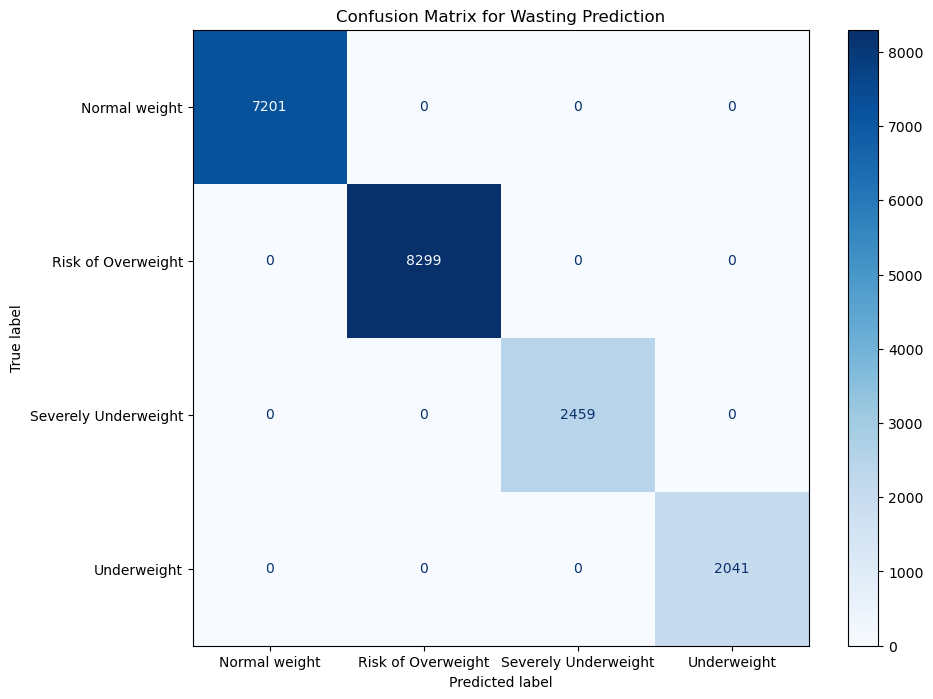

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Confusion Matrix for Wasting Prediction")
plt.show()

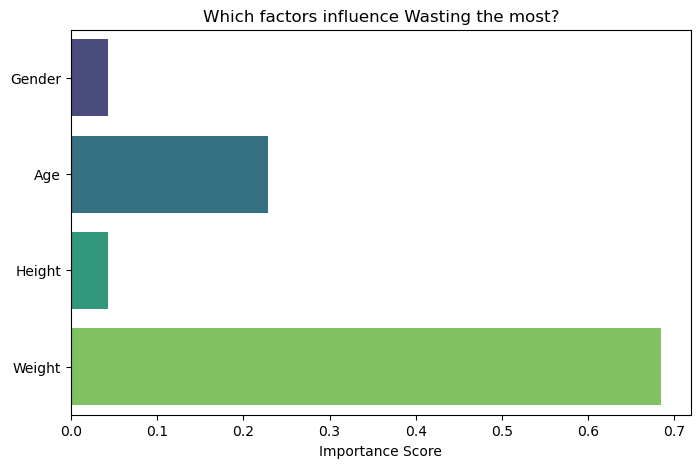

In [53]:
# --- FEATURE IMPORTANCE CELL ---
importances = model_wasting.feature_importances_
feature_names = ['Gender', 'Age', 'Height', 'Weight']

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Which factors influence Wasting the most?")
plt.xlabel("Importance Score")
plt.show()

In [52]:
# --- MASTER DEMO: COMPLETE DIAGNOSIS ---

# 1. Input child data (Change these during your demo!)
name = "Budi"
gender = "Laki-laki" 
age = 240            # months
height = 167      # cm (Try a low height like 55.0 to see 'Severely Stunted')
weight = 30        # kg (Try a low weight like 4.0 to see 'Severely Underweight')

# 2. Process data
gender_enc = le_gender.transform([gender])[0]
child_features = [[gender_enc, age, height, weight]]

# 3. Get both predictions
res_stunting = model_stunting.predict(child_features)[0]
res_wasting = model_wasting.predict(child_features)[0]

# 4. Show the "Bio-Report"
print(f"--- BIOLOGICAL ASSESSMENT FOR {name.upper()} ---")
print(f"Status: {gender}, {age} months old")
print(f"Growth: {height} cm / {weight} kg")
print("-" * 40)
print(f"STUNTING DIAGNOSIS : {res_stunting}")
print(f"WASTING DIAGNOSIS  : {res_wasting}")
print("-" * 40)

--- BIOLOGICAL ASSESSMENT FOR BUDI ---
Status: Laki-laki, 240 months old
Growth: 167 cm / 30 kg
----------------------------------------
STUNTING DIAGNOSIS : Tall
WASTING DIAGNOSIS  : Risk of Overweight
----------------------------------------
